In [ ]:
!pip install torchinfo
!pip install onnxscript
!pip install onnx2tf
!pip install onnxruntime

In [ ]:
import sys
import tensorflow as tf
import numpy as np
import google.protobuf
import requests

try:
    import onnx
    onnx_v = onnx.__version__
except:
    onnx_v = "not installed"

try:
    import onnx2tf
    onnx2tf_v = onnx2tf.__version__
except:
    onnx2tf_v = "not installed"

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Protobuf:", google.protobuf.__version__)
print("Requests:", requests.__version__)
print("ONNX:", onnx_v)
print("onnx2tf:", onnx2tf_v)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0
NumPy: 1.26.4
Protobuf: 4.25.5
Requests: 2.32.5
ONNX: 1.20.1
onnx2tf: 2.0.19


In [ ]:
from pathlib import Path
import requests
import zipfile
import os
import shutil

# Data ve image path olusturalim
data_path = Path("/content/data/")
image_path = Path(data_path / "fruits")

if image_path.is_dir():
  print("File already exist")
else:
  print("Creating file...")
  image_path.mkdir(parents=True, exist_ok=True)

# Data yi zip indirelim
with open(data_path / "fruits.zip", "wb") as f:
  print("Downloading data...")
  request = requests.get("  https://www.kaggle.com/api/v1/datasets/download/muhriddinmuxiddinov/fruits-and-vegetables-dataset")
  f.write(request.content)

# Zip dosyasini acalim
with zipfile.ZipFile(data_path / "fruits.zip","r") as zip_ref:
  print("Unzipping file...")
  zip_ref.extractall(image_path)

# Zip dosyasini silelim
os.remove(data_path / "fruits.zip")
print("Removing zip file...")
print("Data is ready")

Creating file...
Unzipping file...
Removing zip file...
Data is ready


In [ ]:
shutil.move("/content/data/fruits/Fruits_Vegetables_Dataset(12000)/Fruits","/content/data")
shutil.rmtree("/content/data/fruits/Fruits_Vegetables_Dataset(12000)/Vegetables")
shutil.rmtree("/content/data/fruits")
old_path = Path("/content/data/Fruits")
new_path = Path("/content/data/fruits")
old_path.rename(new_path)

PosixPath('/content/data/fruits')

In [ ]:
for item in os.listdir(image_path):
  path = os.path.join(image_path, item)
  if item.startswith("Rotten"):
    shutil.rmtree(path)

In [ ]:
os.mkdir(image_path / "train")
os.mkdir(image_path / "test")
train_dir = Path(image_path / "train")
test_dir = Path(image_path / "test")

In [ ]:
def create_test_train_folders(image_path, train_dir, test_dir, prefix="Fresh"):
    for item in os.listdir(image_path):
        if item.startswith(prefix):
            src_dir = image_path / item
            (train_dir / item).mkdir(parents=True, exist_ok=True)
            (test_dir / item).mkdir(parents=True, exist_ok=True)

            files = os.listdir(src_dir)
            n_test = int(len(files) * 0.2)

            for img in files[:n_test]:
                shutil.move(src_dir / img, test_dir / item)

            for img in os.listdir(src_dir):
                shutil.move(src_dir / img, train_dir / item)
            if not os.listdir(src_dir):
              shutil.rmtree(src_dir)

In [ ]:
create_test_train_folders(image_path=image_path, train_dir=train_dir, test_dir=test_dir)

In [ ]:
from glob import glob
image_path_list = list(Path(image_path).glob("*/*/*"))
len(image_path_list)

3053

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
import torchvision
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 168MB/s]


In [ ]:
import torchvision.datasets as datasets
from torchvision import transforms
auto_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(root=train_dir,
                                     transform=auto_transform)
test_dataset = datasets.ImageFolder(root=test_dir,
                                    transform=auto_transform)

In [ ]:
train_dataset, test_dataset

(Dataset ImageFolder
     Number of datapoints: 2445
     Root location: /content/data/fruits/train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset ImageFolder
     Number of datapoints: 608
     Root location: /content/data/fruits/test
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ))

In [ ]:
class_names = train_dataset.classes
class_names

['FreshApple', 'FreshBanana', 'FreshMango', 'FreshOrange', 'FreshStrawberry']

In [ ]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=32,
                              shuffle=True,
                              num_workers=2,
                              )
test_dataloader = DataLoader(dataset=test_dataset,
                              batch_size=32,
                              shuffle=False,
                              num_workers=2,
                              )

In [ ]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [ ]:
import torch
from torch import nn

for param in model.features.parameters():
  param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(class_names), bias=True)
)
model = model.to(device)

In [ ]:
def train_step(model,loss_fn,optimizer,dataloader,device):
  model.train()
  train_loss = 0
  train_acc = 0
  for batch, (X,y) in enumerate(dataloader):
    X = X.to(device)
    y = y.to(device)

    train_preds = model(X)

    loss = loss_fn(train_preds, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    train_pred_classes = torch.argmax(train_preds, dim=1)

    train_acc += (train_pred_classes == y).sum().item()/len(train_preds)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc

In [ ]:
def test_step(model,dataloader,loss_fn,device):
  model.eval()
  test_loss = 0
  test_acc = 0
  with torch.inference_mode():
    for batch, (X,y) in enumerate(dataloader):
      X = X.to(device)
      y = y.to(device)

      test_pred = model(X)

      loss = loss_fn(test_pred, y)
      test_loss += loss.item()

      test_pred_classes = torch.argmax(test_pred, dim=1)
      test_acc += ((test_pred_classes == y).sum().item()/len(test_pred_classes))

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)

  return test_loss, test_acc

In [ ]:
from tqdm import tqdm
def train(model,train_dataloader,test_dataloader,optimizer,loss_fn,device,epochs):
  results = {
      "train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
               loss_fn=loss_fn,
               optimizer=optimizer,
               dataloader=train_dataloader,
               device=device)
    test_loss, test_acc = test_step(model=model,
              dataloader=test_dataloader,
              loss_fn=loss_fn,
              device=device)
    print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
      )
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [ ]:
model.eval()

summary(
    model,
    input_size=(1, 3, 224, 224),  # senin input boyutun
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3
)

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [1, 3, 224, 224]          [1, 5]                    --                        Partial
├─Sequential: 1-1                                       [1, 3, 224, 224]          [1, 1280, 7, 7]           --                        False
│    └─Conv2dNormActivation: 2-1                        [1, 3, 224, 224]          [1, 32, 112, 112]         --                        False
│    │    └─Conv2d: 3-1                                 [1, 3, 224, 224]          [1, 32, 112, 112]         (864)                     False
│    │    └─BatchNorm2d: 3-2                            [1, 32, 112, 112]         [1, 32, 112, 112]         (64)                      False
│    │    └─SiLU: 3-3                                   [1, 32, 112, 112]         [1, 32, 112, 112]         --                        --
│    └─Sequential

In [ ]:
results_app_1 = train(model=model,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      device=device,
      epochs=5)
results_app_1

 20%|██        | 1/5 [00:12<00:49, 12.40s/it]

Epoch: 1 | train_loss: 0.6244 | train_acc: 0.8683 | test_loss: 0.2071 | test_acc: 0.9819


 40%|████      | 2/5 [00:24<00:35, 11.95s/it]

Epoch: 2 | train_loss: 0.2046 | train_acc: 0.9688 | test_loss: 0.1033 | test_acc: 0.9901


 60%|██████    | 3/5 [00:35<00:23, 11.88s/it]

...

 80%|████████  | 4/5 [00:47<00:11, 11.79s/it]

Epoch: 4 | train_loss: 0.1096 | train_acc: 0.9799 | test_loss: 0.0563 | test_acc: 0.9918


100%|██████████| 5/5 [00:59<00:00, 11.83s/it]

Epoch: 5 | train_loss: 0.0839 | train_acc: 0.9866 | test_loss: 0.0433 | test_acc: 0.9934


{'train_loss': [0.6244034236901767,
  0.204633891582489,
  0.13910582700333038,
  0.10962314052241189,
  0.08392213807477579],
 'train_acc': [0.8683191808191808,
  0.96875,
  0.9809253246753247,
  0.9799263236763236,
  0.9866071428571429],
 'test_loss': [0.2070658667699287,
  0.10334469211336814,
  0.06882568934050046,
  0.05634077623682587,
  0.04332196007874843],
 'test_acc': [0.9819078947368421,
  0.9901315789473685,
  0.9901315789473685,
  0.9917763157894737,
  0.993421052631579]}

In [ ]:
import matplotlib.pyplot as plt
def create_plot(results):
  fig, axes =plt.subplots(2,2, figsize=(10,7))
  axes[0,0].plot(results["train_loss"])
  axes[0,0].set_xlabel("Epochs")
  axes[0,0].set_ylabel("Train Loss")

  axes[0,1].plot(results["train_acc"])
  axes[0,1].set_xlabel("Epochs")
  axes[0,1].set_ylabel("Train Acc")

  axes[1,0].plot(results["test_loss"])
  axes[1,0].set_xlabel("Epochs")
  axes[1,0].set_ylabel("Test Loss")

  axes[1,1].plot(results["test_acc"])
  axes[1,1].set_xlabel("Epochs")
  axes[1,1].set_ylabel("Test Acc")

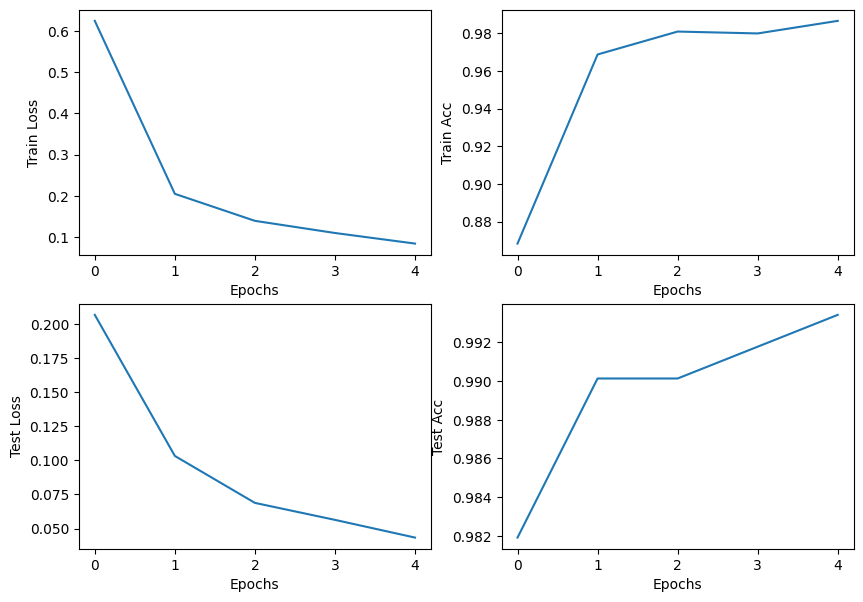

In [ ]:
create_plot(results_app_1)

In [ ]:
model = model.cpu()
model.eval()

dummy = torch.randn(1, 3, 224, 224).cpu()  # kendi input boyutun neyse
torch.onnx.export(
    model,
    dummy,
    "model.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=13
)

W0222 10:51:04.969000 3556 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0222 10:51:05.926000 3556 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0222 10:51:05.928000 3556 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 98 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,224,224]>
            ),
            outputs=(
                %"output"<FLOAT,[1,5]>
            ),
            initializers=(
                %"features.0.0.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"features.1.0.block.0.0.weight"<FLOAT,[32,1,3,3]>{Tensor(...)},
                %"features.1.0.block.1.fc1.weight"<FLOAT,[8,32,1,1]>{TorchTensor(...)},
                %"features.1.0.block.1.fc1.bias"<FLOAT,[8]>{TorchTensor<FLOAT,[8]>(Parameter containing: tensor([-1.2193, -0.1298, -1.2465, -1.0992, -1.7503, -1.8147, -1.5511, -0.7177]), name='features.1.0.block.1.fc1.bias')},
                %"features.1.0.block.1.fc2.weight"<FLOAT,[

In [ ]:
import onnx
onnx_model = onnx.load("model.onnx")
onnx.checker.check_model(onnx_model)

In [ ]:
!onnx2tf -i model.onnx -o saved_model


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add        │ 9              │ 9                │
│ Constant   │ 166            │ 166              │
│ Conv       │ 81             │ 81               │
│ Gemm       │ 1              │ 1                │
│ Mul        │ 65             │ 65               │
│ ReduceMean │ 17             │ 17               │
│ Reshape    │ 1              │ 1                │
│ Sigmoid    │ 65             │ 65               │
│ Model Size │ 15.8MiB        │ 15.3MiB          │
└────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ 

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
converter.optimizations = []   # şimdilik quantization yapma
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

In [ ]:
import numpy as np
import tensorflow as tf
from PIL import Image
import requests
from io import BytesIO

def url_tahmin(model_paths, img_url ):
  interpreter = tf.lite.Interpreter(
      model_path= model_paths
  )
  interpreter.allocate_tensors()

  input_details = interpreter.get_input_details()
  output_details = interpreter.get_output_details()

  print("Giriş şekli:", input_details[0]['shape'])
  print("Giriş tipi:", input_details[0]['dtype'])
  print("Çıkış şekli:", output_details[0]['shape'])
  print("Çıkış tipi:", output_details[0]['dtype'])


  image_url = img_url

  response = requests.get(image_url)
  img = Image.open(BytesIO(response.content)).convert("RGB")
  img = img.resize((224, 224))

  img_array = np.array(img).astype(np.float32) / 255.0

  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  img_array = (img_array - mean) / std

  input_data = np.expand_dims(img_array, axis=0).astype(np.float32)

  interpreter.set_tensor(input_details[0]['index'], input_data)
  interpreter.invoke()
  output_data = interpreter.get_tensor(output_details[0]['index'])

  def softmax(x):
      exp_x = np.exp(x - np.max(x))
      return exp_x / exp_x.sum()

  scores = softmax(output_data[0])
  predicted_class = np.argmax(scores)

  print(f"\nTahmin: {class_names[predicted_class]}")
  print(f"Güven: %{scores[predicted_class]*100:.1f}")

  print("Top 3:")
  top3_idx = np.argsort(scores)[-3:][::-1]
  for idx in top3_idx:
      print(f"{class_names[idx]}: %{scores[idx]*100:.1f}")

In [ ]:
url_tahmin(model_paths="/content/model.tflite",
           img_url="https://www.fidandeposu.com/washington-navel-portakal-fidani-portakal-fidani-695-19-B.jpg")

Giriş şekli: [  1 224 224   3]
Giriş tipi: <class 'numpy.float32'>
Çıkış şekli: [1 5]
Çıkış tipi: <class 'numpy.float32'>

Tahmin: FreshOrange
Güven: %80.2
Top 3:
FreshOrange: %80.2
FreshApple: %16.1
FreshStrawberry: %2.6
